<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-6-Improvements_NN/Untitled172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importance Sampling -- An Integral Operator**

**Uniform sampling**


Let $x_k \sim \mathrm{Unif}[0,1]$. The loss function is
$$
L(\theta)
=
\mathbb{E}_{x \sim \mathrm{Unif}[0,1]}
\big( F_\theta'(x) - f(x) \big)^2
+
\mu \big( F_\theta(0) \big)^2,
$$
which, in discrete form, becomes
$$
L(\theta)
=
\frac{1}{N} \sum_{k=1}^N
\big( F_\theta'(x_k) - f(x_k) \big)^2
+
\mu \big( F_\theta(0) \big)^2.
$$
We consider the case $f(x) = \sin x$.

/tmp/ipykernel_7200/3602567770.py:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss_history.append(float(loss.numpy()))


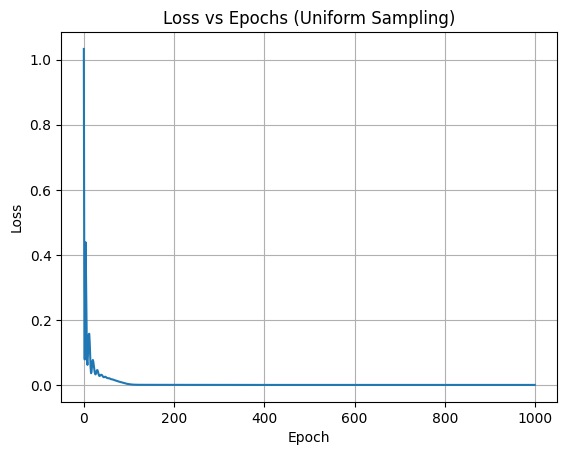

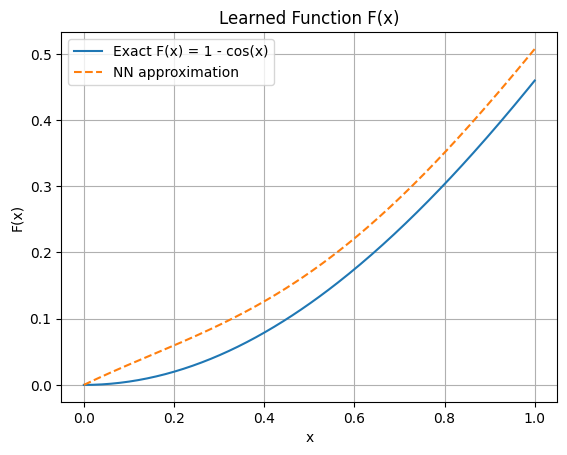

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
tf.random.set_seed(0)
np.random.seed(0)

# ----------------------------
# Problem setup
# ----------------------------
# Choose f(x)
def f_np(x):
    return np.sin(x)

def f_tf(x):
    return tf.sin(x)

# Exact solution F(x) = ∫0^x sin(t) dt = 1 - cos(x)
def F_exact(x):
    return 1.0 - np.cos(x)

# ----------------------------
# Collocation points
# ----------------------------
N = 10
xk = np.random.uniform(0.0, 1.0, size=(N, 1)).astype(np.float32)
xk_tf = tf.constant(xk)

# ----------------------------
# Neural network F_theta(x)
# ----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)

# penalty weight for initial condition
mu = 10.0

# ----------------------------
# Training loop
# ----------------------------
epochs = 1000
loss_history = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        # Compute F_theta(x)
        with tf.GradientTape() as tape2:
            tape2.watch(xk_tf)
            F_val = model(xk_tf)
        dF_dx = tape2.gradient(F_val, xk_tf)

        # Compute residual
        residual = dF_dx - f_tf(xk_tf)

        # Loss: PDE + initial condition
        loss_pde = tf.reduce_mean(tf.square(residual))
        loss_ic = tf.square(model(tf.constant([[0.0]])))

        loss = loss_pde + mu * loss_ic

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(float(loss.numpy()))

# ----------------------------
# Plot loss vs epochs
# ----------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Uniform Sampling)")
plt.grid(True)
plt.show()

# ----------------------------
# Plot learned F(x)
# ----------------------------
x_plot = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)
F_pred = model(tf.constant(x_plot)).numpy().reshape(-1)
F_true = F_exact(x_plot)

plt.figure()
plt.plot(x_plot, F_true, label="Exact F(x) = 1 - cos(x)")
plt.plot(x_plot, F_pred, "--", label="NN approximation")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Learned Function F(x)")
plt.legend()
plt.grid(True)
plt.show()

## **Importance sampling**



Let $x_k$ be the same collocation points, but assign weights through a learned distribution
$\phi_\theta(x_k)$, with
$$
\phi_\theta(x_k) \ge 0,
\qquad
\sum_{k=1}^N \phi_\theta(x_k) = 1.
$$
The loss function becomes
$$
L(\theta)
=
\mathbb{E}_{x \sim \phi_\theta}
\big( F_\theta'(x) - f(x) \big)^2
+
\mu \big( F_\theta(0) \big)^2,
$$
or, in discrete form,
$$
L(\theta)
=
\sum_{k=1}^N
\phi_\theta(x_k)
\big( F_\theta'(x_k) - f(x_k) \big)^2
+
\mu \big( F_\theta(0) \big)^2.
$$
Again, consider $f(x) = \sin x$.

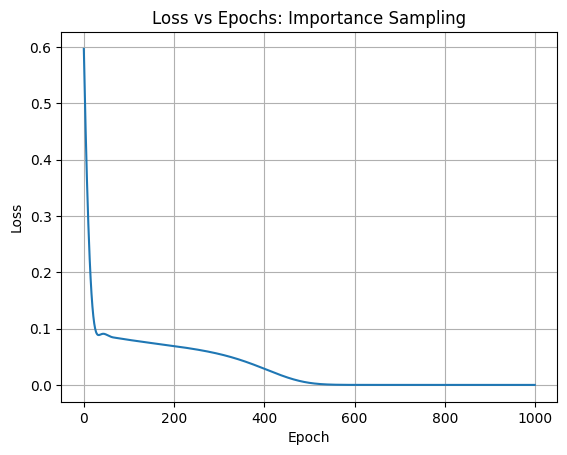

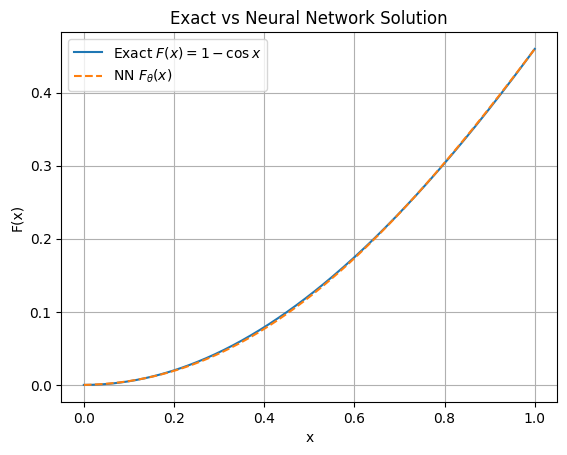

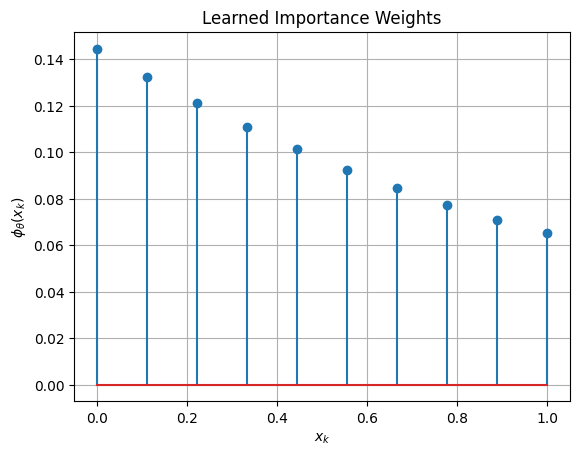

Learned weights:
x_01 = 0.0000, phi(x_k) = 0.144550
x_02 = 0.1111, phi(x_k) = 0.132315
x_03 = 0.2222, phi(x_k) = 0.121027
x_04 = 0.3333, phi(x_k) = 0.110651
x_05 = 0.4444, phi(x_k) = 0.101147
x_06 = 0.5556, phi(x_k) = 0.092469
x_07 = 0.6667, phi(x_k) = 0.084566
x_08 = 0.7778, phi(x_k) = 0.077389
x_09 = 0.8889, phi(x_k) = 0.070885
x_10 = 1.0000, phi(x_k) = 0.065000

Check normalization:
sum phi = 1.0
min phi = 0.065000355


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
tf.random.set_seed(0)
np.random.seed(0)

# ----------------------------
# Problem setup
# f(x) = sin(x), F(x) = ∫_0^x sin(t) dt = 1 - cos(x)
# ----------------------------
def f_tf(x):
    return tf.sin(x)

def F_exact_np(x):
    return 1.0 - np.cos(x)

# ----------------------------
# Collocation points
# ----------------------------
N = 10
xk = np.linspace(0.0, 1.0, N).reshape(-1, 1).astype(np.float32)
xk_tf = tf.constant(xk)

# ----------------------------
# Neural network for F_theta(x)
# ----------------------------
F_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

# ----------------------------
# Neural network for phi_theta(x)
# raw_phi -> softmax weights
# ----------------------------
phi_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

mu = 10.0
epochs = 1000

loss_history = []

# ----------------------------
# Training loop
# ----------------------------
for ep in range(epochs):
    with tf.GradientTape() as tape:

        # Compute F_theta'(x)
        with tf.GradientTape() as tape_x:
            tape_x.watch(xk_tf)
            F_val = F_model(xk_tf)

        dF_dx = tape_x.gradient(F_val, xk_tf)

        # Residual: F'(x) - sin(x)
        residual = dF_dx - f_tf(xk_tf)

        # Learned weights phi_theta(x_k)
        raw_phi = phi_model(xk_tf)                 # shape (N,1)
        weights = tf.nn.softmax(raw_phi[:, 0])     # shape (N,)

        # Weighted residual loss
        residual_sq = tf.square(residual[:, 0])
        loss_residual = tf.reduce_sum(weights * residual_sq)

        # Initial condition loss
        F0 = F_model(tf.constant([[0.0]], dtype=tf.float32))
        loss_ic = tf.square(F0[0, 0])

        # Total loss
        loss = loss_residual + mu * loss_ic

    variables = F_model.trainable_variables + phi_model.trainable_variables
    grads = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(grads, variables))

    loss_history.append(float(loss.numpy()))

# ----------------------------
# Extract learned weights
# ----------------------------
raw_phi = phi_model(xk_tf)
weights = tf.nn.softmax(raw_phi[:, 0]).numpy()

# ----------------------------
# Plot 1: Loss vs epochs
# ----------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Importance Sampling")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2: Exact and NN solution F(x)
# ----------------------------
x_plot = np.linspace(0.0, 1.0, 300).reshape(-1, 1).astype(np.float32)

F_pred = F_model(tf.constant(x_plot)).numpy().reshape(-1)
F_true = F_exact_np(x_plot).reshape(-1)

plt.figure()
plt.plot(x_plot, F_true, label=r"Exact $F(x)=1-\cos x$")
plt.plot(x_plot, F_pred, "--", label=r"NN $F_\theta(x)$")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Exact vs Neural Network Solution")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3: Learned weights phi(x_k)
# ----------------------------
plt.figure()
plt.stem(xk.reshape(-1), weights)
plt.xlabel(r"$x_k$")
plt.ylabel(r"$\phi_\theta(x_k)$")
plt.title("Learned Importance Weights")
plt.grid(True)
plt.show()

# ----------------------------
# Print learned weights
# ----------------------------
print("Learned weights:")
for i in range(N):
    print(f"x_{i+1:02d} = {xk[i,0]:.4f}, phi(x_k) = {weights[i]:.6f}")

print("\nCheck normalization:")
print("sum phi =", np.sum(weights))
print("min phi =", np.min(weights))